<img src="https://userweb.fct.unl.pt/~jmc.xavier/MAI/iLogos/logo_novafct.png" style="width: 20%;">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica Aplicada I 

## ANÁLISE DE VIGAS

### Problema 2 <a name="PII"></a>

A viga indicada na figura está encastrada na extremidade B e suporta uma força horizontal  $F = 1$ kN  aplicada em C e uma carga distribuída variando
linearmente entre as secções A e B.  Na secção A, $Q_A = $ 2 kN e na secção B, $Q_B = $ 1 kN.  Na extremidade C está ainda suspensa uma massa $m = 100$ kg.

[a)](#A)  Calcule a posição do centróide da superfície representando o carregamento distribuído aplicado.

[b)](#B)  Calcule as reações no apoio B.

[c)](#C)  Escreva as equações dos esforços internos no troço AB da viga e trace os respectivos diagramas.

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P2/MAI_Ch08_P2.jpg"
style="width: 40%;">

#### Resumo

**Determinação de Esforços em vigas**

Metodologia:

- Diagrama de corpo livre;
- Determinar reações nos apoios;
- Determinar os esforços internos (esforço transverso e momento flector);
- Desenhar os diagramas de esforço transverso e momento flector.

Programas de análise estrutural:

- [Ftool](https://www.ftool.com.br/Ftool/)
- [ANSYS Student](https://www.ansys.com/academic/free-student-products)
- [Robot Structural Analysis Professional](https://www.autodesk.com/education/free-software/featured)


### Resolução

#### a) Calcule a posição do centróide da superfície representando o carregamento distribuído aplicado. <a id="A"></a> ([_enunciatum_](#PII))

**Carregamento distribuído**

A carga linearmente distribuida ao longo da barra AB pode ser definida por uma função polinomial descrita pela equação genérica da reta:

\begin{equation*}
y - y_0 = m (x- x_0)~,\quad\textrm{com}\quad
m = \frac{y_1-y_0}{x_1-x_0}
\end{equation*}

Em que $P_0(x_0,y_0)$ e $P_1(x_1,y_1)$ são os pontos extremos do segmento de reta. Para um referencial orientado ao longo da barra AB e com origem em A, têm-se:

\begin{equation*}
\begin{aligned}
P_0(0,Q_A)\quad\textrm{e}\quad P_1(L,Q_B)
\quad\therefore\quad
w(x) - Q_A &= \frac{Q_B - Q_A}{L}x\\
~\Leftrightarrow~
w(x) &= Q_A - \frac{Q_A - Q_B}{L}x \\
~\Leftrightarrow~
w(x) &= 2 - \frac{1}{4}x
\end{aligned}
\end{equation*}

De notar que efetivamente verifica-se: $w(x=0) = Q_A~;~w(x=L) = Q_B$.

In [10]:
import numpy as np
import sympy as sy

# Dados | Unidades: m, kN, kg

L = 4.  # unit: m
W = 1.  # unit: m
QA = 2. # unit: kN/m
QB = 1. # unit: kN/m
F = 1. # unit: kN
m = 100. # unit: kg
g = 9.81 # unit: m/s^2
P = m*g*1e-3
print(f'P (massa) = {P:.3f} kN')

P (massa) = 0.981 kN


**Força equivalente ao carregamento distribuído**

Para o cálculo das reações (forças de superfície que se desenvolvem nos apoios ou pontos de contato entre os corpos) é conveniente substituir a força distribuida por uma força resultante aplicada no centroide da área geométrica definida pelo carregamento (trapézio escaleno). Esta força equivalente é apenas usada, contudo, para o cálculo das resções e não para o desenvolvimento algébrico do método das secções para a determinação dos esforços/diagramas de esforços.

A resultante da força linearmente distribuida pode ser calculada pelo seguinte integral,

\begin{equation*}
\begin{aligned}
P_\textrm{eq} &= \int_0^L w(x)\mathrm{d}x
= \int_0^L \left(Q_A - \frac{Q_A - Q_B}{L}x\right)\,\mathrm{d}x \\
&=Q_A [x]_0^L - \left(\frac{Q_A - Q_B}{L}\right)
\left[\frac{x^2}{2}\right]_0^L\\
&=  Q_A L - \left(\frac{Q_A - Q_B}{L}\right)\frac{L^2}{2}\\
&= \frac{L}{2}( Q_A + Q_B ) = 6~\textrm{kN}
\end{aligned}
\end{equation*}

ou,

\begin{equation*}
\begin{aligned}
P_\textrm{eq} &= A = \int_0^L\int_0^{2-x/4} \mathrm{d}x\mathrm{d}y
= \int_0^L\left[2-\frac{x}{4}\right] \,\mathrm{d}x \\
&=\left[2x-\frac{x^2}{8}\right]_0^L = 6~\textrm{kN}
\end{aligned}
\end{equation*}

In [11]:
def printsymSF(expr):
    expr2 = sy.simplify(sy.factor(expr))
    return expr2.xreplace({n : round(n, 3) for n in expr2.atoms(sy.Number)})

qa, qb, l, x = sy.symbols('qa qb l x')

f = qa - (qa-qb)/l*x # integrant function
i1 = sy.integrate(f, (x,0,l))
Peq = i1.subs({(qa,QA),(qb,QB),(l,L)})
print(f'Peq = {sy.simplify(i1)} = {Peq:.1f} [kN]')

print('\nEm alternativa (scipy)...')
from scipy import integrate

w = lambda z : QA - (QA-QB)/L*z
int2 = integrate.quad(w,0,L)
print('Resultante = ',int2)
Peq2 = int2[0]
print(f'Peq = {Peq2:.1f} [kN]')

Peq = l*(qa + qb)/2 = 6.0 [kN]

Em alternativa (scipy)...
Resultante =  (6.0, 6.661338147750939e-14)
Peq = 6.0 [kN]


**Definição do centróide da área definida pelo carregamento distribuído aplicado**

O ponto de aplicação da força é o centróide da área definida pela curva $w(x)$. O valor do centróide pode ser calculado de acordo com a expressão:

\begin{equation*}
\begin{aligned}
\overline{x} = \frac{Q_y}{A}
&= \displaystyle\frac{\displaystyle\int_0^L w(x)x~\mathrm{d}x
}{\displaystyle\int_0^L w(x)\mathrm{d}x}
= \displaystyle\frac{L^2(Q_A + 2Q_B)/6
}{L(Q_A + Q_B)/2} \\
&= L\frac{Q_A + 2Q_B}{3(Q_A + Q_B)}
= \frac{16}{9} = 1.778~\textrm{m}
\end{aligned}
\end{equation*}

ou,

\begin{equation*}
\begin{aligned}
\overline{x} = \frac{Q_y}{A}
&= \frac{\displaystyle\int x\,\mathrm{d}A}{\displaystyle\int \mathrm{d}A}
= \displaystyle\frac{\displaystyle\int_0^L\int_0^{2-x/4}
x\,\mathrm{d}x\mathrm{d}y
}{P_\textrm{eq}} \\
&= \displaystyle\frac{1}{P_\textrm{eq}}\displaystyle\int_0^L
\left(2x - \frac{x^2}{4} \right)\mathrm{d}x
= \left[x^2 - \frac{x^3}{12} \right]_0^L
= 1.778~\textrm{m}
\end{aligned}
\end{equation*}

In [12]:
f = (qa - (qa-qb)/l*x)*x
i2 = sy.integrate(f, (x,0,l))
print(f'   Qy = {sy.simplify(i2)} = {i2.subs({(qa,QA),(qb,QB),(l,L)}):.3f} [kN]')

xcexp = i2/i1
xcent = xcexp.subs({(qa,QA),(qb,QB),(l,L)})
print(f'xcent = {sy.simplify(xcexp)} = {sy.N(xcent):.3f} [m]')

   Qy = l**2*(qa + 2*qb)/6 = 10.667 [kN]
xcent = l*(qa + 2*qb)/(3*(qa + qb)) = 1.778 [m]


**Princípio de sobreposição**

De notar que, em alternativa (embora não corresponda ao pedido no enunciado), a solução do exercício poderia passar por considerar, pelo princípio de sobreposição, o carregamento distribuido como a combinação de dois carregamentos cujas distribuições são definidas por áreas simples. Neste caso:

- Um retângulo de comprimento $L$ e altura $Q_B$;

    Resultante das forças: $Q_b L$

    Centoide do ponto de aplicação da força resultante: $L/2$

- Um triângulo de comprimento $L$ e altura em A: $Q_A-Q_B$ e em B: 0;

    Resultante das forças: $(Q_A-Q_B) L/2$

    Centoide do ponto de aplicação da força resultante: $L/3$

#### b) Calcule as reações no apoio B.  <a id="B"></a> ([_enunciatum_](#PII))

Para se calcular as reações, desenha-se o DCL conforme se ilustra na figura:

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P2/MAI_Ch08_P2eq2.jpg"
width="600">

O equilíbrio estático da viga plana permite escrever o seguinte sistema de equações escalares:

\begin{equation*}
\begin{cases}
\sum F_x = 0 \\
\sum F_y = 0 \\
\sum M_B = 0
\end{cases}~\Leftrightarrow~
\begin{cases}
F - R_{Bx} = 0 \\
- mg - P_\textrm{eq} + R_{By} = 0 \\
F \cdot L_y + mg\cdot L + P_\textrm{eq} \cdot (L-\overline{x}) - M_B = 0
\end{cases}
\end{equation*}

onde $L_y=1$ m e $L=4$ m. De onde resulta,

\begin{equation*}
\begin{cases}
\sum F_x = 0 \\
\sum F_y = 0 \\
\sum M_B = 0
\end{cases}~\Leftrightarrow~
\begin{cases}
R_{Bx} = F = 1000~\textrm{N}\\
R_{By} = mg + P_\textrm{eq} = 6981~\textrm{N} \\
M_B = F \cdot L_y + mg\cdot L + P_\textrm{eq} \cdot (L-\overline{x})
= 18257~\textrm{N.m}
\end{cases}
\end{equation*}

In [13]:
from sympy.solvers import solve

MA = F*W
print(f'MA = {MA:.2f} kN.m')# unit: kN.m (momento externo

# diretamente aplicado)

print('-------------------')
print('Sistema de equações')
print('-------------------')
rbx, rby, mb = sy.symbols('rbx rby mb')

sumFx = F - rbx
print('Sum Fx :',sumFx)
sumFy = -P - Peq + rby
print('Sum Fy :',sumFy)
sumMA =  MA + P*L +  Peq*(L-xcent) - mb
print('Sum sumMA :',printsymSF(sumMA))
sol = solve({sumFx,sumFy, sumMA},{rbx, rby, mb})

MA = 1.00 kN.m
-------------------
Sistema de equações
-------------------
Sum Fx : 1.0 - rbx
Sum Fy : rby - 6.981
Sum sumMA : 18.257 - 1.0*mb


In [14]:
print('-------------------')
print('Reações')
print('-------------------')
RBx = sol[rbx]
print(f'RAx  = {RBx:.3f} [kN]')
RBy = sol[rby]
print(f'RAy  = {RBy:.3f} [kN]')
MB = sol[mb]
print(f'MB   = {MB:.3f} [kN.m]')

-------------------
Reações
-------------------
RAx  = 1.000 [kN]
RAy  = 6.981 [kN]
MB   = 18.257 [kN.m]


#### c) Escreva as equações dos esforços internos no troço AB da viga e trace os respectivos diagramas.  <a id="C"></a> ([_enunciatum_](#PII))

**Troço $~0<y<L_y$**

Para definir os esforços internos da consola, começa-se por cortar a parte vertical. Daqui, resultam três esforços internos identificados na figura abaixo por $N_1(y)$, $V_1(y)$ e $M_1(y)$ correspondentes ao esforço normal, esforço transverso e momento flector da barra vertical, respectivamente. Note-se ainda que $y$ varia entre 0 e 1 m.

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P2/MAI_Ch08_P2FMeq.jpg"
style="max-width: 100%;"/>

\begin{equation*}
\begin{cases}
\sum F_x = 0 \\
\sum F_y = 0 \\
\sum M = 0
\end{cases}
~\Leftrightarrow~
\begin{cases}
F + V_1(y) = 0 \\
- mg + N_1(y) = 0 \\
F \cdot y + M_1(y) = 0
\end{cases}
~\Leftrightarrow~
\begin{cases}
V_1(y) = -F = -1~\textrm{kN} \\
N_1(y) = - mg = 0,981~\textrm{kN} \\
M_1(y) = -F \cdot y = -y ~\textrm{kN.m}
\end{cases}
\end{equation*}

Verifica-se que o esforço normal e o esforço transverso são constantes no troço vertical, e que o momento flector varia linearmente de 0 (em C) até -1 kNm (em A).

Para definir os esforços no troço AB da consola, é preciso perceber como se processam os esforços em A. Assim, a figura abaixo mostra que o que é esforço transverso em A do troço AC passa a esforço normal no troço AB. De igual forma, o que é esforço normal em A do troço AC passa a esforço transverso no troço AB. Note-se ainda que os esforços no Ponto A de ambos os troços são marcados atendendo à 3ª lei de Newton.

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P2/MAI_Ch08_P2FMeq2.jpg"
style="max-width: 100%;"/>

__Sistema força-momento__

Fixando a análise apenas à viga AB, de notar que o mesmo exercício poderia ter sido abordado considerando a equivalência para um sistema força-momento. Neste caso as forças aplicadas no ponto C seriam transferidas como um sistema força-momento no ponto A:

- A força vertical $mg$ seria diretamente transferida do ponto C para o ponto A pelo princípio da transmissibilidade (que estabelece que as condições de equilíbrio ou de movimento de um corpo rígido não se alteram se substituirmos uma força atuando num ponto do corpo por outra força com a mesma intensidade, direção e sentido, mas atuando noutro ponto do corpo, desde que as duas forças tenham a mesma linha de ação).
- A força horizontal $F = 1$ kN é transferida para o ponto A, com a mesma intensidade, direção e sentido.
- É considerado no ponto A um momento aplicado resultante da ação dos momentos gerados pelas forças iniciais em relação ao ponto A. Neste caso apenas a força horizontal, $F$ exerce um momento em relação ao ponto A de
valor: $M_A = F\cdot d = 1$ kN.m.



**Troço $~0<x<L$**

**Solução 1**

Faz-se um corte no troço AB da consola a uma distância arbitrária $x$ de A (com $x \in [0, 4[$ m) e procede-se ao equilíbrio da parte cortada. O DCL  ilustrado na figura abaixo ajuda a identificar os três esforços do troço AB: esforço normal $N_2 (x)$, esforço transverso $V_2(x)$ e momento flector $M_2(x)$.

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P2/MAI_Ch08_P2msec.jpg"
style="max-width: 100%;"/>

Assim, das três equações de equilíbrio seguintes, determinam-se as leis que definem os três esforços internos no troço AB da consola:

\begin{equation*}
\begin{cases}
\sum F_x = 0 \\
\sum F_y = 0 \\
\sum M_0 = 0 \\
\end{cases}~\Leftrightarrow~
\begin{cases}
F + N(x) = 0 \\
-mg - \displaystyle\int_0^xw(x)\mathrm{d}x - V(x) = 0 \\
M_A + mg\cdot x +
\displaystyle\int_0^xw(x)\mathrm{d}x\left(x-\frac{\displaystyle\int_0^xw(x)x\mathrm{d}x}{\displaystyle\int_0^xw(x)\mathrm{d}x}\right) +M(x)= 0 \\
\end{cases}
\end{equation*}

\begin{equation*}
\qquad\qquad~\Leftrightarrow~
\begin{cases}
V(x) =  1 ~\textrm{(kN)} \\
V(x) =  0.125\,x^2 - 2\,x - 0.981 ~\textrm{(kN)} \\
M(x) =  0.0417\,x^3 - x^2 - 0.981\,x - 1.0 ~\textrm{(kN.m)}
\end{cases}
\end{equation*}


In [15]:
n, v, m, x = sy.symbols('n v m x')

print('-------------------')
print('Sistema de equações')
print('-------------------')
sumFx = F + n
print('--->>>> sumFx = ',sumFx)
f = qa - (qa-qb)/l*x # integrant function
ib1 = sy.integrate(f, (x,0,x))
print('int w(x) = ',ib1)
sumFy = - P - ib1 - v
print(f'--->>>> sumFy = {sumFy}')
print(f'              = {sumFy.subs({(qa,QA),(qb,QB),(l,L)})}')
f2 = f*x
ib2 = sy.integrate(f2, (x,0,x))
print('int w(x)x = ',printsymSF(ib2))
sumMA = MA + P*x + ib1*(x-ib2/ib1) + m
print(f'--->>>> sumMA = {printsymSF(sumMA)}')
print(f'              = {printsymSF(sumMA.subs({(qa,QA),(qb,QB),(l,L)}))}')
sol = solve({sumFx,sumFy,sumMA},{n,v,m})

-------------------
Sistema de equações
-------------------
--->>>> sumFx =  n + 1.0
int w(x) =  qa*x + x**2*(-qa + qb)/(2*l)
--->>>> sumFy = -qa*x - v - 0.981 - x**2*(-qa + qb)/(2*l)
              = -v + 0.125*x**2 - 2.0*x - 0.981
int w(x)x =  x**2*(0.5*l*qa - 0.333*qa*x + 0.333*qb*x)/l
--->>>> sumMA = 1.0*m + 0.5*qa*x**2 + 0.981*x + 1.0 - 0.167*qa*x**3/l + 0.167*qb*x**3/l


              = 1.0*m - 0.042*x**3 + 1.0*x**2 + 0.981*x + 1.0


In [16]:
print('-------------------')
print('Esforços')
print('-------------------')
Nx = sol[n]
print(f'N(x) = {Nx:.2f} [kN]')
Nx2 = Nx.subs({(qa,QA),(qb,QB),(l,L)})
Vx = sol[v]
print('V(x) = ',printsymSF(Vx),' [kN]')
Vx2 = Vx.subs({(qa,QA),(qb,QB),(l,L)})
print('     = ',printsymSF(Vx2),' [kN]')
Mx = sol[m]
print('M(x) = ',printsymSF(Mx),' [kN.m]')
Mx2 = Mx.subs({(qa,QA),(qb,QB),(l,L)})
print('     = ',printsymSF(Mx2),' [kN.m]')

-------------------
Esforços
-------------------
N(x) = -1.00 [kN]
V(x) =  -1.0*qa*x - 0.981 + 0.5*qa*x**2/l - 0.5*qb*x**2/l  [kN]
     =  0.125*x**2 - 2.0*x - 0.981  [kN]
M(x) =  -0.5*qa*x**2 - 0.981*x - 1.0 + 0.167*qa*x**3/l - 0.167*qb*x**3/l  [kN.m]
     =  0.042*x**3 - 1.0*x**2 - 0.981*x - 1.0  [kN.m]



**Solução 2**


Por simplicidade, as expressões do esforço transverso e momento fletor podem ser determinadas por integração ao longo do troço da viga com carregamento distribuído,

\begin{equation*}
V_2(x) - V_A = - \int_0^x w(x) \mathrm{d}x
\Leftrightarrow
V_2(x) = -0,981 - \int_0^x \left(2 - \frac{x}{4}\right) \mathrm{d}x
\end{equation*}

De notar que no desenvolvimento da expresão anterior, $V_A$ é assumido positivo de baixo para cima (corte à esquerda). Neste caso, portanto o valor de $V_A = -0,981$ kN.

\begin{equation*}
M_2(x) - M_A = \int_0^x V_2(x) \mathrm{d}x
\Leftrightarrow
M_2(x) = -1 + \int_0^x \left(\frac{x^2}{8} - 2\,x - 0,981\right) \mathrm{d}x
\end{equation*}

De notar que no desenvolvimento da expresão anterior, $M_A$ é considerado positivo no sentido horário (corte à esquerda). Neste caso portanto o valor de $M_A = -1$ kN.m.

desenvolvendo,

\begin{equation*}
M_2(x) = -1 + \left[\frac{x³}{12} - x² - 0.981x\right]_0^x
\Leftrightarrow
M_2(x) = \frac{x³}{24} - x² - 0.981x -1
\end{equation*}



In [17]:
vii, mii = sy.symbols('vii mii')

print('-------------------------------------------')
print('Sistema de equações & Eforços (v2)')
print('-------------------------------------------')
expVx = vii + P + ib1
#print(f'expVx = {printsymSF(expVx)}')
sol = solve(expVx,vii)
Vx22 = sol[0]
print(f'V(x) = {printsymSF(Vx22.subs({(qa,QA),(qb,QB),(l,L)}))} [kN]')
ii3 = sy.integrate(Vx2, (x,0,x))
#print(f'ii3 = {printsymSF(ii3)}')
expMx = mii + MA - ii3
#print(f'expMx = {printsymSF(sumMA)}')
sol = solve(expMx,mii)
Mx22 = sol[0]
print(f'M(x) = {printsymSF(Mx22.subs({(qa,QA),(qb,QB),(l,L)}))} [kN.m]')

-------------------------------------------
Sistema de equações & Eforços (v2)
-------------------------------------------
V(x) = 0.125*x**2 - 2.0*x - 0.981 [kN]
M(x) = 0.042*x**3 - 1.0*x**2 - 0.981*x - 1.0 [kN.m]


#### c) Traçe os diagramas dos esforços internos indicando o valor máximo do momento flector.  <a id="C"></a> ([_enunciatum_](#PII))

Os valores do esforço transverso e do momento flector em A e em B obtêm-se substituindo o valor da coordenada $x$ nestes dois pontos:

In [18]:
print('----------------------')
print('Eforços (pontos A e B)')
print('----------------------')
xi, xf = 0, L
print(f'V(0) = {Vx2.subs(x,xi):.3f} kN')
print(f'V(L) = {Vx2.subs(x,xf):.3f} kN')
print(f'\nM(0) = {Mx2.subs(x,xi):.3f} kN.m')
print(f'M(L) = {Mx2.subs(x,xf):.3f} kN.m')

----------------------
Eforços (pontos A e B)
----------------------
V(0) = -0.981 kN
V(L) = -6.981 kN

M(0) = -1.000 kN.m
M(L) = -18.257 kN.m


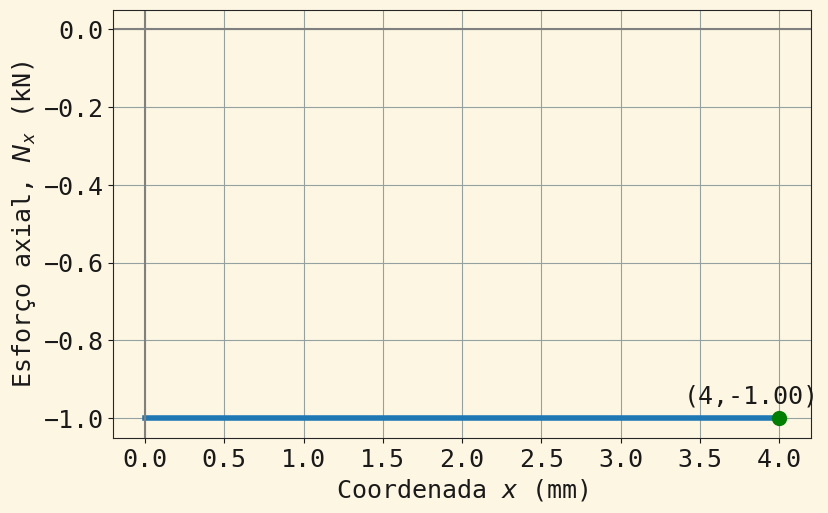

In [19]:
xp = np.linspace(0,L,1000)

import matplotlib.pyplot as plt

# Define a switch for the color theme
use_light_theme = True

if use_light_theme:
    # Solarized Light Theme Colors
    background_color = (253/255, 246/255, 227/255)
    font_color = (0.1, 0.1, 0.1)
    grid_color = (147/255, 161/255, 161/255)
else:
    # Dark Theme Colors
    background_color = (.15, .15, .15)
    font_color = (.8, .8, .8)
    grid_color = (.2, .2, .2)

plt.rcParams['axes.facecolor'] = background_color
plt.rcParams['figure.facecolor'] = background_color
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.size'] = 18
# plt.rcParams['text.usetex'] = True

params = {
    "ytick.color": font_color,
    "xtick.color": font_color,
    "grid.color": grid_color,
    "text.color": font_color,
    "axes.labelcolor": font_color,
    "axes.edgecolor": (.15, .15, .15)
}

plt.rcParams.update(params)

def sy2array(syfunc,xlist):
    scalar_func = lambda xx: float(syfunc.evalf(subs={x: xx}))
    vector_func = np.vectorize(scalar_func)
    return vector_func(xlist)

Nplot = sy2array(Nx2,xp) #
Vplot = sy2array(Vx2,xp) #
Mplot = sy2array(Mx2,xp) #

plt.figure(figsize=(9,5.56))
plt.plot(xp,Nplot,linewidth=4)
plt.axhline(y=0, color='gray', linestyle='-')
plt.axvline(x=0, color='gray', linestyle='-')
plt.plot(xp[-1],Nplot[-1],'go',markersize=10)
plt.text(xp[-1]*.85,Nplot[-1]*.96,f'({xp[-1]:.0f},{Nplot[-1]:.2f})',fontsize=18)
plt.xlabel('Coordenada $x$ (mm)')
plt.ylabel('Esforço axial, $N_{x}$ (kN)')
plt.grid(True)
plt.show()


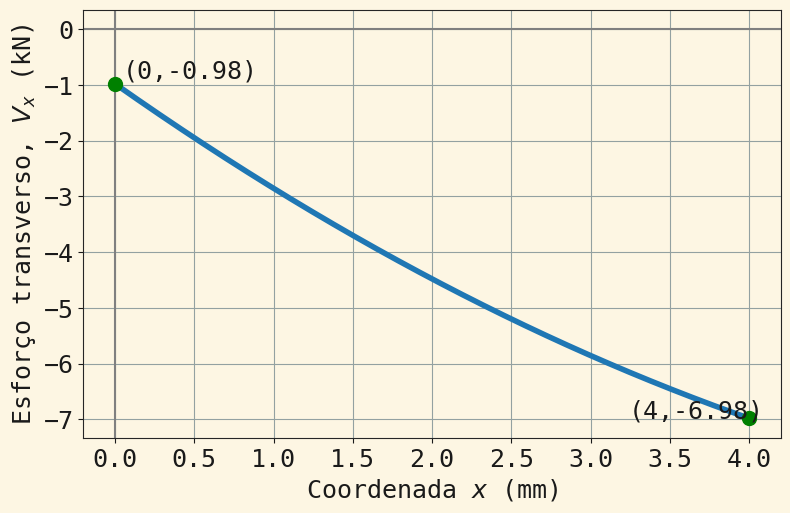

In [20]:
plt.figure(figsize=(9,5.56))
plt.plot(xp,Vplot,linewidth=4)
plt.axhline(y=0, color='gray', linestyle='-')
plt.axvline(x=0, color='gray', linestyle='-')
plt.plot(xp[0],Vplot[0],'go',markersize=10)
plt.text(xp[0]+.05,Vplot[0]*.9,f'({xp[0]:.0f},{Vplot[0]:.2f})',fontsize=18)
plt.plot(xp[-1],Vplot[-1],'go',markersize=10)
plt.text(xp[-1]*.81,Vplot[-1]*1.,f'({xp[-1]:.0f},{Vplot[-1]:.2f})',fontsize=18)
plt.xlabel('Coordenada $x$ (mm)')
plt.ylabel('Esforço transverso, $V_{x}$ (kN)')
plt.grid(True)
plt.show()


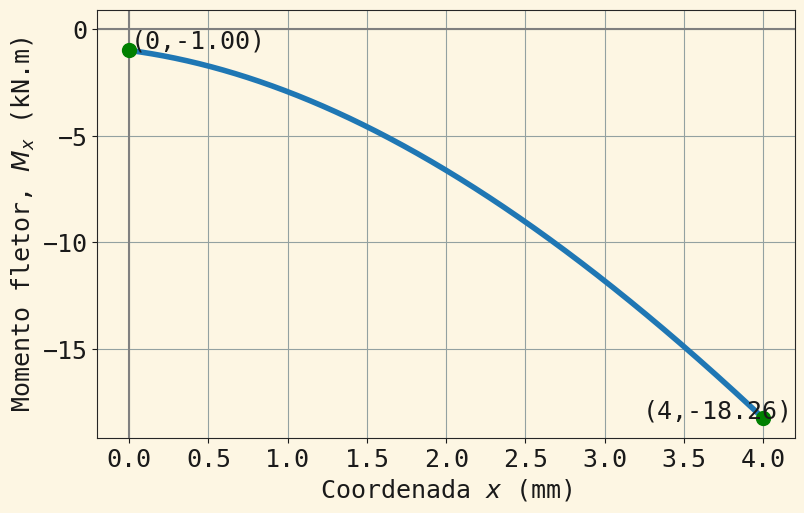

In [21]:
plt.figure(figsize=(9,5.56))
plt.plot(xp,Mplot,linewidth=4)
plt.axhline(y=0, color='gray', linestyle='-')
plt.axvline(x=0, color='gray', linestyle='-')
plt.plot(xp[0],Mplot[0],'go',markersize=10)
plt.text(xp[0]+.01,Mplot[0]*.9,f'({xp[0]:.0f},{Mplot[0]:.2f})',fontsize=18)
plt.plot(xp[-1],Mplot[-1],'go',markersize=10)
plt.text(xp[-1]*.81,Mplot[-1]*1.,f'({xp[-1]:.0f},{Mplot[-1]:.2f})',fontsize=18)
plt.xlabel('Coordenada $x$ (mm)')
plt.ylabel('Momento fletor, $M_{x}$ (kN.m)')
plt.grid(True)
plt.show()

**Diagrama de Esforços**

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P2/MAI_Ch08_P2diags.jpg"
style="max-width: 100%;"/>


---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>